In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
def carregar_cinza(caminho):
    """Carrega uma imagem colorida e converte para tons de cinza."""
    img_bgr = cv2.imread(caminho)
    if img_bgr is None:
        raise FileNotFoundError(f"Não foi possível abrir: {caminho}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)


def histograma(img, bins=256, faixa=(0, 256)):
    """Calcula o histograma de uma imagem em tons de cinza."""
    hist = cv2.calcHist([img], [0], None, [bins], faixa)
    return hist.flatten()


def expandir_contraste(img, L=None, H=None):
    """
    Expansão linear de contraste (stretching).
    Mapeia o intervalo [L, H] presente na imagem para [0, 255].
    Se L/H não forem informados, usa o mínimo e máximo da própria imagem.
    """
    if L is None:
        L = int(img.min())
    if H is None:
        H = int(img.max())

    img_float = img.astype(np.float32)
    img_exp = (img_float - L) * (255.0 / (H - L))
    return np.clip(img_exp, 0, 255).astype(np.uint8)


def equalizar(img):
    """Equalização de histograma (OpenCV)."""
    return cv2.equalizeHist(img)


def corrigir_gamma(img, gamma=1.0):
    """
    Correção de gamma: saida = 255 * (entrada/255) ** (1/gamma)
    gamma > 1 clareia a imagem; gamma < 1 escurece.
    """
    inv_gamma = 1.0 / gamma
    tabela = np.array([
        ((i / 255.0) ** inv_gamma) * 255
        for i in range(256)
    ]).astype("uint8")
    return cv2.LUT(img, tabela)


def resumo_estatistico(img):
    """Retorna média, desvio padrão, mínimo e máximo de intensidade."""
    return {
        "media": float(np.mean(img)),
        "desvio_padrao": float(np.std(img)),
        "min": int(img.min()),
        "max": int(img.max()),
    }


def plotar_antes_depois(img_antes, img_depois, titulo):
    """Monta a figura com antes/depois e os dois histogramas."""
    fig, eixos = plt.subplots(2, 2, figsize=(10, 8))

    eixos[0, 0].imshow(img_antes, cmap="gray", vmin=0, vmax=255)
    eixos[0, 0].set_title("Antes")
    eixos[0, 0].axis("off")

    eixos[0, 1].imshow(img_depois, cmap="gray", vmin=0, vmax=255)
    eixos[0, 1].set_title("Depois")
    eixos[0, 1].axis("off")

    eixos[1, 0].plot(histograma(img_antes), color="black")
    eixos[1, 0].set_title("Histograma - Antes")
    eixos[1, 0].set_xlim([0, 256])
    eixos[1, 0].set_xlabel("Intensidade")
    eixos[1, 0].set_ylabel("Nº de pixels")

    eixos[1, 1].plot(histograma(img_depois), color="black")
    eixos[1, 1].set_title("Histograma - Depois")
    eixos[1, 1].set_xlim([0, 256])
    eixos[1, 1].set_xlabel("Intensidade")
    eixos[1, 1].set_ylabel("Nº de pixels")

    fig.suptitle(titulo, fontsize=14)
    fig.tight_layout()
    plt.show()

Estatísticas (antes): {'media': 16.864330837992355, 'desvio_padrao': 13.655938033111955, 'min': 0, 'max': 64}


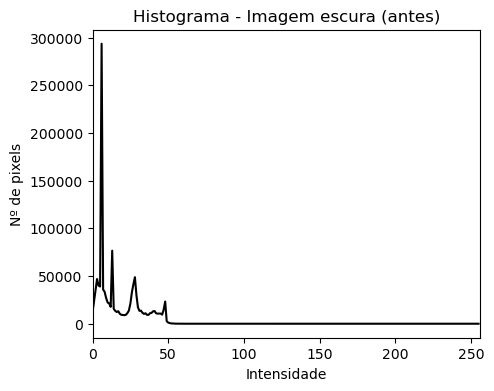

In [8]:
caminho_escura = "fotos/escuro.jpg"  # <-- ajuste o caminho

img_escura = carregar_cinza(caminho_escura)
print("Estatísticas (antes):", resumo_estatistico(img_escura))

plt.figure(figsize=(5, 4))
plt.plot(histograma(img_escura), color="black")
plt.title("Histograma - Imagem escura (antes)")
plt.xlim([0, 256])
plt.xlabel("Intensidade")
plt.ylabel("Nº de pixels")
plt.show()

* A imagem possui muitos valores baixos no histograma (<50), o que dificulta a visualização de suas características.

Estatísticas (depois): {'media': 66.46671088789918, 'desvio_padrao': 54.6122429528747, 'min': 0, 'max': 255}


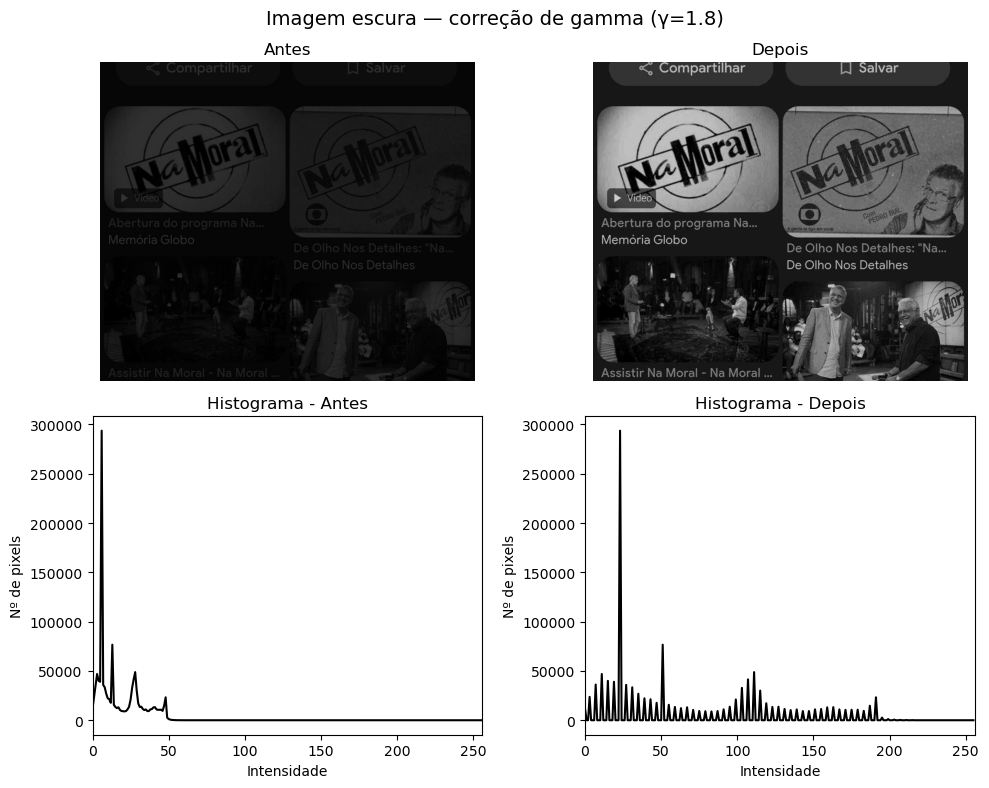

In [16]:
img_escura_corrigida = expandir_contraste(img_escura)
print("Estatísticas (depois):", resumo_estatistico(img_escura_corrigida))

plotar_antes_depois(img_escura, img_escura_corrigida, f"Imagem escura — correção de gamma (γ={gamma_escura})")

Estatísticas (antes): {'media': 178.15973871979952, 'desvio_padrao': 81.36621374150792, 'min': 0, 'max': 255}


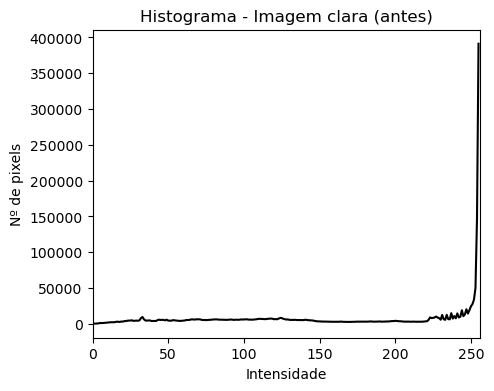

In [ ]:
caminho_clara = "./fotos/claro.jpg"  # <-- ajuste o caminho

img_clara = carregar_cinza(caminho_clara)
print("Estatísticas (antes):", resumo_estatistico(img_clara))

plt.figure(figsize=(5, 4))
plt.plot(histograma(img_clara), color="black")
plt.title("Histograma - Imagem clara (antes)")
plt.xlim([0, 256])
plt.xlabel("Intensidade")
plt.ylabel("Nº de pixels")
plt.show()

Estatísticas (depois): {'media': 150.14646655551297, 'desvio_padrao': 100.89364119527622, 'min': 0, 'max': 255}


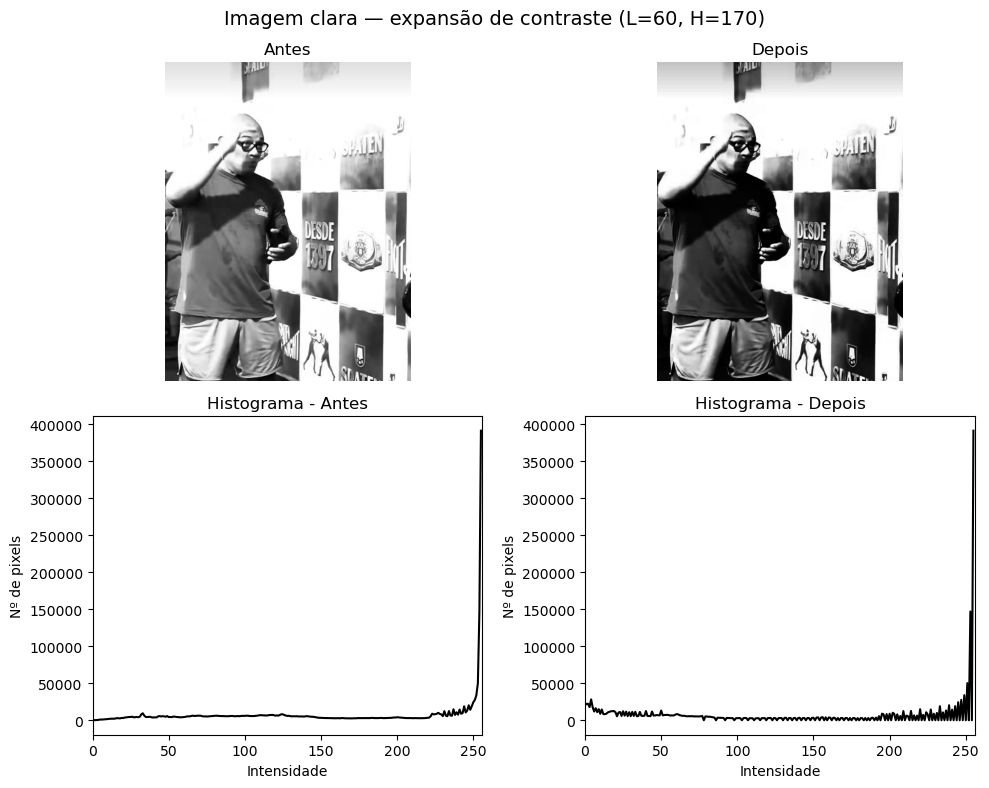

In [24]:
gamma=0.5

img_clara_corrigida = corrigir_gamma(img_clara, gamma=gamma)
print("Estatísticas (depois):", resumo_estatistico(img_clara_corrigida))

plotar_antes_depois(img_clara, img_clara_corrigida, f"Imagem clara — expansão de contraste (L={L_clara}, H={H_clara})")

Estatísticas (antes): {'media': 117.38609202922255, 'desvio_padrao': 55.45343174491392, 'min': 0, 'max': 255}


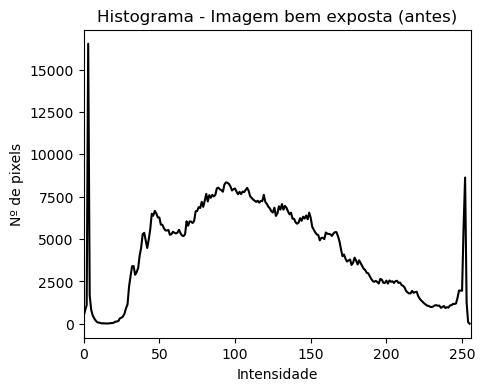

In [25]:
caminho_bem_exposta = "./fotos/normal.jpg"  # <-- ajuste o caminho

img_bem_exposta = carregar_cinza(caminho_bem_exposta)
print("Estatísticas (antes):", resumo_estatistico(img_bem_exposta))

plt.figure(figsize=(5, 4))
plt.plot(histograma(img_bem_exposta), color="black")
plt.title("Histograma - Imagem bem exposta (antes)")
plt.xlim([0, 256])
plt.xlabel("Intensidade")
plt.ylabel("Nº de pixels")
plt.show()

Estatísticas (depois): {'media': 128.12791771162722, 'desvio_padrao': 73.5523569776437, 'min': 0, 'max': 255}


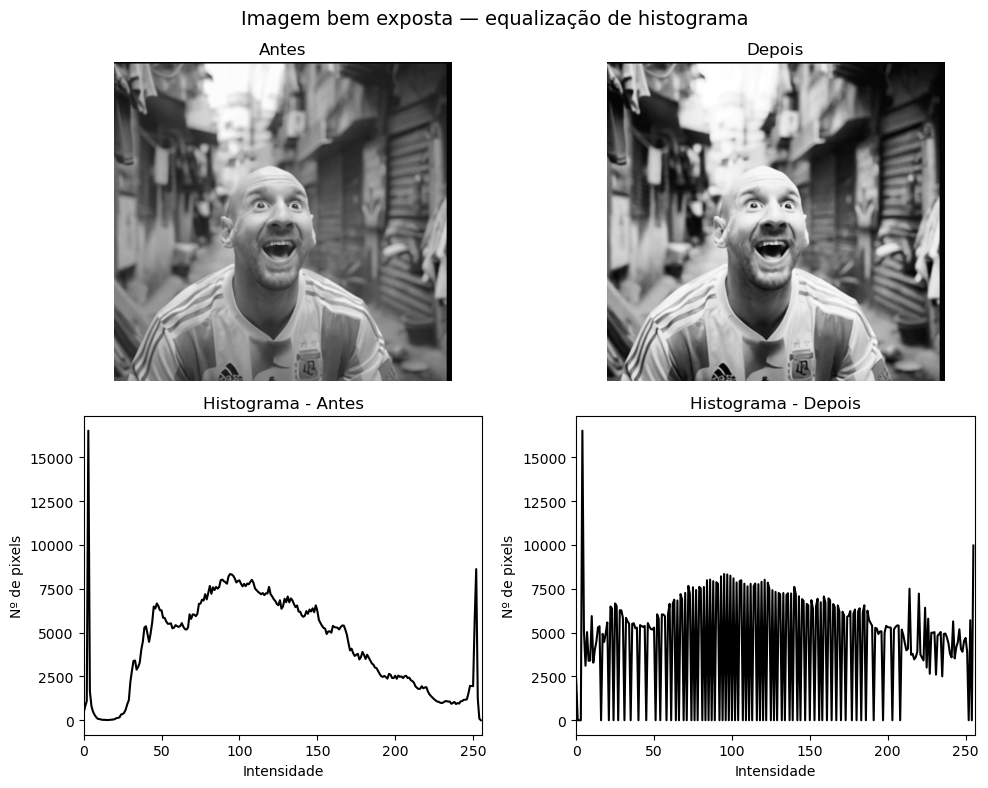

In [26]:
img_bem_exposta_corrigida = equalizar(img_bem_exposta)
print("Estatísticas (depois):", resumo_estatistico(img_bem_exposta_corrigida))

plotar_antes_depois(img_bem_exposta, img_bem_exposta_corrigida, "Imagem bem exposta — equalização de histograma")